# Khởi động & Kiểm tra Thuật toán (Synthetic Data)

> **Lưu ý quan trọng**: Đây là notebook DUY NHẤT sử dụng dữ liệu giả (synthetic data). Mục đích của notebook này chỉ là để xác minh (validate) tính đúng đắn của các thuật toán CP-ALS và CP-OPT được cài đặt từ đầu bằng NumPy, đảm bảo chúng có thể khôi phục lại các factor matrices đã biết.

In [2]:
import sys
import os

# Thêm thư mục cha (chứa thư mục src) vào sys.path
sys.path.append(os.path.abspath(os.path.join('..')))

import numpy as np
import matplotlib.pyplot as plt

# Bây giờ bạn có thể import từ src bình thường
from src.cp_als import cp_als, reconstruct
from src.cp_opt import cp_opt
from src.evaluate import relative_error, factor_similarity
from src.visualize import plot_convergence, plot_reconstruction_error

# Đặt seed để kết quả có thể tái tạo
np.random.seed(42)


## 1. Tính Robustness: FMS vs Noise Level

Tạo tensor rank 3. Quét qua nhiều mức độ nhiễu khác nhau, chạy CP-ALS và tính Factor Match Score (FMS) so với ground truth `true_factors`.

Evaluating noise robustness...


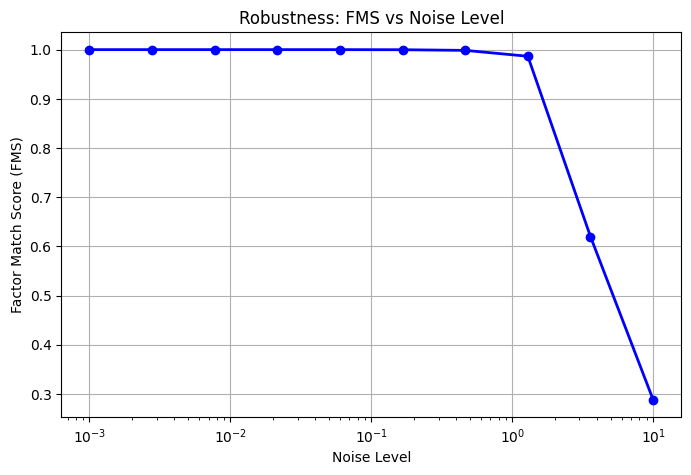

In [8]:
shape = (10, 15, 20)
true_rank = 3
true_factors = [np.random.randn(s, true_rank) for s in shape]
X_true = reconstruct(true_factors)

noise_levels = np.logspace(-3, 1, 10)
fms_scores = []

print("Evaluating noise robustness...")
for noise in noise_levels:
    E = np.random.randn(*shape)
    X_noisy = X_true + noise * E * (np.linalg.norm(X_true) / np.linalg.norm(E))
    
    # Đã sửa: lấy 3 factor matrices A, B, C và gom lại thành list
    weights, A, B, C = cp_als(X_noisy, rank=true_rank, max_iter=100, tol=1e-6)
    factors_als = [A, B, C]
    
    # Compare recovered factors against true_factors (ground truth)
    _, mean_sim, _ = factor_similarity(true_factors, factors_als, greedy_permutation=True)
    fms_scores.append(mean_sim)

plt.figure(figsize=(8, 5))
plt.semilogx(noise_levels, fms_scores, 'bo-', linewidth=2)
plt.xlabel('Noise Level')
plt.ylabel('Factor Match Score (FMS)')
plt.title('Robustness: FMS vs Noise Level')
plt.grid(True)
plt.show()


## 2. Lựa chọn Rank (Elbow Plot) & So sánh CP-ALS vs CP-OPT

Cố định mức nhiễu nhỏ. Quét qua các rank từ 1 đến 8, chạy cả CP-ALS và CP-OPT để vẽ đường cong Reconstruction Error vs Rank (elbow plot).

Evaluating ranks...


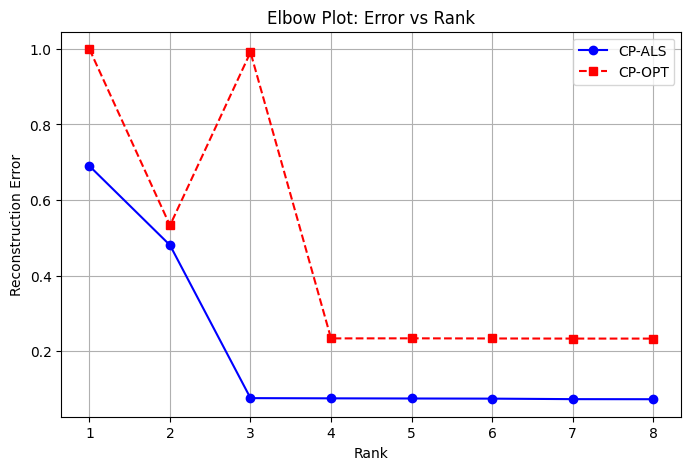

In [10]:
X_test = X_true + 0.1 * np.random.randn(*shape)
ranks = list(range(1, 9))
errs_als = []
errs_opt = []

print("Evaluating ranks...")
for r in ranks:
    # --- ĐÃ SỬA CHỖ NÀY ---
    # Bắt lấy A, B, C từ cp_als và gom thành f_als
    w_als, A, B, C = cp_als(X_test, rank=r, max_iter=100, tol=1e-6)
    f_als = [A, B, C]
    X_hat_als = reconstruct(f_als, w_als)
    errs_als.append(relative_error(X_test, X_hat_als))
    # ----------------------
    
    # Ở hàm cp_opt thì vẫn giữ nguyên (vì nó trả về f_opt là dạng list hợp lệ rồi)
    w_opt, f_opt, info_opt = cp_opt(X_test, rank=r, max_iter=100, tol=1e-6)
    X_hat_opt = reconstruct(f_opt, w_opt)
    errs_opt.append(relative_error(X_test, X_hat_opt))

plt.figure(figsize=(8, 5))
plt.plot(ranks, errs_als, 'bo-', label='CP-ALS')
plt.plot(ranks, errs_opt, 'rs--', label='CP-OPT')
plt.xlabel('Rank')
plt.ylabel('Reconstruction Error')
plt.title('Elbow Plot: Error vs Rank')
plt.legend()
plt.grid(True)
plt.show()
